# Curso de Data Science · UTN FRBA — Centro de e-Learning
# **Trabajo Final Integrador**
Actividades desarrolladas:
1. Búsqueda y selección del dataset.
2. Ingesta y limpieza (Python).
3. Exploración y visualización.
4. Construcción de Dashboard → en Power BI.
5. Crear publicación → en GitHub.

##Datos del alumno
| Campo | Dato |
|---|---|
| Nombre del alumno | Victoria Estefanía Cardoso |
| Fecha de entrega | 19/08/2026 |


---
# 1.Selección y alcance del dataset



## 1.1 Descripción del dataset elegido

- **Nombre / fuente:** Global Mental Health & Lifestyle, Kaggle (Salud mental y estilo de vida a nivel mundial).
- **Link de descarga:** https://www.kaggle.com/datasets/farshaddavoodifard/global-mental-health-and-lifestyle-5k-records?select=synthetic_depression_dataset_v2_5000.csv
- **Formato:** `.csv`
- **Cantidad de filas y columnas:** 500, 26.
- **Diccionario de data set con unidades:**

| Variable | Descripción | Tipo de dato | Unidad / Valores posibles (original) | Traducción de unidades / valores |
|----------|-------------|--------------|--------------------------------------|----------------------------------|
| `id` | Identificador único del participante | `object` | Código alfanumérico (ej.: `user_075722`) | Identificador único del participante |
| `country` | País de residencia del participante | `object` | Italy, Spain, Sweden, France, Germany, Netherlands | Italia, España, Suecia, Francia, Alemania, Países Bajos |
| `average_sunny_days` | Promedio anual de días soleados del país | `int64` | Days per year | Días por año |
| `age` | Edad del participante | `int64` | Years (18–80) | Años (18–80) |
| `gender` | Género del participante | `object` | Male, Female, Other | Masculino, Femenino, Otro |
| `employment_status` | Situación laboral | `object` | Employed, Unemployed, Student, Retired | Empleado, Desempleado, Estudiante, Jubilado |
| `marital_status` | Estado civil | `object` | Single, Married, Divorced, Widowed | Soltero/a, Casado/a, Divorciado/a, Viudo/a |
| `education_level` | Máximo nivel educativo alcanzado | `object` | High School, Bachelor, Master, PhD | Secundario, Licenciatura, Maestría, Doctorado |
| `monthly_income` | Rango de ingreso mensual | `object` | `<1000€`, `1000–2000€`, `2000–3000€`, `3000–5000€`, `>5000€` | Menos de 1000 €, entre 1000 y 2000 €, entre 2000 y 3000 €, entre 3000 y 5000 €, más de 5000 € |
| `loneliness` | Frecuencia con la que la persona experimenta soledad | `object` | Occasional, Frequent, NaN | Ocasional, Frecuente, Sin dato |
| `faith` | Posee creencias religiosas | `bool` | True, False | Sí, No |
| `migration_background` | Posee antecedentes migratorios | `bool` | True, False | Sí, No |
| `overeating` | Presenta hábitos de sobrealimentación | `bool` | True, False | Sí, No |
| `physical_inactivity` | Presenta inactividad física | `bool` | True, False | Sí, No |
| `high_sugar_intake` | Consume grandes cantidades de azúcar | `bool` | True, False | Sí, No |
| `energy_drink_consumption` | Consume bebidas energéticas | `bool` | True, False | Sí, No |
| `high_coffee_consumption` | Consume café en grandes cantidades | `bool` | True, False | Sí, No |
| `ultra_processed_food` | Consume alimentos ultraprocesados | `bool` | True, False | Sí, No |
| `low_dietary_diversity` | Presenta baja diversidad en la alimentación | `bool` | True, False | Sí, No |
| `alcohol_consumption` | Consume alcohol | `bool` | True, False | Sí, No |
| `smoking` | Fuma | `bool` | True, False | Sí, No |
| `poor_sleep_quality` | Presenta mala calidad del sueño | `bool` | True, False | Sí, No |
| `anxiety_level` | Nivel de ansiedad | `object` | Mild, Moderate, Severe, NaN | Leve, Moderado, Severo, Sin dato |
| `social_media_use_hours` | Tiempo diario de uso de redes sociales | `float64` | Hours per day (0–10) | Horas por día (0–10) |
| `news_hours_per_day` | Tiempo diario dedicado al consumo de noticias | `float64` | Hours per day (0–4) | Horas por día (0–4) |
| `depression_severity` | Nivel de severidad de la depresión | `object` | Mild, Moderate, Severe | Leve, Moderada, Severa |

## 1.2 Definición de objetivos

###Preguntas de investigación

**Pregunta 1:** ¿Cómo varía la proporción de personas con depresión severa entre países con distinta cantidad promedio de días soleados?

**Pregunta 2:** ¿Cómo varía el nivel de ansiedad según el tiempo diario dedicado al consumo de noticias y al uso de redes sociales?

**Pregunta 3:** ¿Qué características sociodemográficas (edad, género y situación laboral) predominan entre las personas con distintos niveles de severidad de la depresión?

### Validación de viabilidad

| Pregunta | Columnas necesarias | ¿Están en el dataset? | ¿Viable? (Sí / Reformular) |
|---|---|---|---|
| **P1** | `country`, `average_sunny_days`, `depression_severity` | Sí | **Sí**. El dataset permite comparar la distribución de la severidad de la depresión entre países y relacionarla con la cantidad promedio de días soleados de cada uno. |
| **P2** | `anxiety_level`, `news_hours_per_day`, `social_media_use_hours` | Sí | **Sí**. Las tres variables están presentes y permiten analizar cómo varía el nivel de ansiedad según el tiempo dedicado al consumo de noticias y al uso de redes sociales. |
| **P3** | `age`, `gender`, `employment_status`, `depression_severity` | Sí | **Sí**. El dataset contiene todas las variables necesarias para describir las características sociodemográficas predominantes en cada nivel de severidad de la depresión. |

##1.3.Importación de librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

##1.4.Carga del dataset

In [4]:
data_set = pd.read_csv('/content/synthetic_depression_dataset_v2_5000.csv')
data_set

,id,country,average_sunny_days,age,gender,employment_status,marital_status,education_level,monthly_income,loneliness,...,high_coffee_consumption,ultra_processed_food,low_dietary_diversity,alcohol_consumption,smoking,poor_sleep_quality,anxiety_level,social_media_use_hours,news_hours_per_day,depression_severity
0,user_075722,Italy,230,26,Other,Student,Married,Bachelor,1000–2000€,Occasional,...,False,False,False,False,False,False,NaN,10.0,2.6,Mild
1,user_080185,Italy,230,64,Other,Student,Widowed,High School,2000–3000€,NaN,...,False,False,False,False,True,True,NaN,7.7,2.2,Moderate
2,user_019865,Spain,250,54,Male,Unemployed,Single,Bachelor,>5000€,NaN,...,False,True,True,True,False,False,NaN,8.4,3.8,Mild
3,user_076700,Sweden,170,51,Male,Retired,Divorced,Master,1000–2000€,NaN,...,True,False,False,True,True,True,Moderate,4.2,1.3,Moderate
4,user_092992,France,200,71,Other,Student,Married,Master,2000–3000€,Frequent,...,False,False,True,True,False,True,NaN,2.6,1.8,Severe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,user_044720,Spain,250,59,Other,Employed,Married,PhD,3000–5000€,Occasional,...,False,True,False,True,False,True,NaN,0.3,2.8,Mild
4996,user_020981,Netherlands,150,29,Other,Unemployed,Widowed,High School,>5000€,Frequent,...,False,False,False,False,False,False,Moderate,8.3,2.8,Moderate
4997,user_057225,Netherlands,150,43,Other,Student,Single,Master,>5000€,NaN,...,True,True,False,True,False,True,Severe,3.0,2.5,Moderate
4998,user_023911,Sweden,170,76,Female,Employed,Married,PhD,<1000€,NaN,...,False,False,False,False,False,False,Severe,6.4,1.1,Moderate


#2.Exploración del dataset

##2.1.Exploración estructural

In [5]:
#Filas y columnas
data_set.shape

(5000, 26)

In [6]:
# Panorama general: columnas, nulos y tipos
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        5000 non-null   object 
 1   country                   5000 non-null   object 
 2   average_sunny_days        5000 non-null   int64  
 3   age                       5000 non-null   int64  
 4   gender                    5000 non-null   object 
 5   employment_status         5000 non-null   object 
 6   marital_status            5000 non-null   object 
 7   education_level           5000 non-null   object 
 8   monthly_income            5000 non-null   object 
 9   loneliness                3354 non-null   object 
 10  faith                     5000 non-null   bool   
 11  migration_background      5000 non-null   bool   
 12  overeating                5000 non-null   bool   
 13  physical_inactivity       5000 non-null   bool   
 14  high_sug

**Lectura del `info()`:**
- 500 filas, 26 columnas.
- El dataset presenta 4 tipos de datos:
  - **`object`**: 10 variables categóricas (por ejemplo, `country`, `gender`, `education_level`).
  - **`int64`**: 2 variables numéricas enteras (`average_sunny_days` y `age`).
  - **`float64`**: 2 variables numéricas decimales (`social_media_use_hours` y `news_hours_per_day`).
  - **`bool`**: 12 variables booleanas que indican la presencia o ausencia de determinados hábitos o características.
- La mayoría de las variables no presentan valores faltantes, ya que cuentan con los 5.000 registros completos.
- No obstante, se detectan valores nulos en dos variables:
  - **`loneliness`**: 3.354 valores no nulos y **1.646 valores faltantes** (32,9 %).
  - **`anxiety_level`**: 3.696 valores no nulos y **1.304 valores faltantes** (26,1 %).

**Dado que ambas variables corresponden a dimensiones subjetivas relacionadas con la salud mental, los valores faltantes podrían estar asociados a la falta de respuesta de los participantes. Sin embargo, al tratarse de un dataset sintético, también podrían formar parte del diseño del conjunto de datos.**
**En la etapa de limpieza se evaluará el tratamiento más adecuado ( eliminación, imputación o conservación) considerando la cantidad de valores faltantes y la relevancia de estas variables para los objetivos planteados.**

In [7]:
#Primeras 5 filas
data_set.head()

,id,country,average_sunny_days,age,gender,employment_status,marital_status,education_level,monthly_income,loneliness,...,high_coffee_consumption,ultra_processed_food,low_dietary_diversity,alcohol_consumption,smoking,poor_sleep_quality,anxiety_level,social_media_use_hours,news_hours_per_day,depression_severity
0,user_075722,Italy,230,26,Other,Student,Married,Bachelor,1000–2000€,Occasional,...,False,False,False,False,False,False,NaN,10.0,2.6,Mild
1,user_080185,Italy,230,64,Other,Student,Widowed,High School,2000–3000€,NaN,...,False,False,False,False,True,True,NaN,7.7,2.2,Moderate
2,user_019865,Spain,250,54,Male,Unemployed,Single,Bachelor,>5000€,NaN,...,False,True,True,True,False,False,NaN,8.4,3.8,Mild
3,user_076700,Sweden,170,51,Male,Retired,Divorced,Master,1000–2000€,NaN,...,True,False,False,True,True,True,Moderate,4.2,1.3,Moderate
4,user_092992,France,200,71,Other,Student,Married,Master,2000–3000€,Frequent,...,False,False,True,True,False,True,NaN,2.6,1.8,Severe


In [8]:
# Tipos de variables (para confirmar formatos)
data_set.dtypes

,0
id,object
country,object
average_sunny_days,int64
age,int64
gender,object
employment_status,object
marital_status,object
education_level,object
monthly_income,object
loneliness,object


In [9]:
#Valores/Unidades de cada variable
for columna in data_set.columns:
    print(f"\n--- {columna} ---")
    print(data_set[columna].unique())


--- id ---
['user_075722' 'user_080185' 'user_019865' ... 'user_057225' 'user_023911'
 'user_041657']

--- country ---
['Italy' 'Spain' 'Sweden' 'France' 'Germany' 'Netherlands']

--- average_sunny_days ---
[230 250 170 200 160 150]

--- age ---
[26 64 54 51 71 78 45 34 37 60 57 61 46 36 74 31 21 73 62 28 75 77 53 76
 23 65 58 56 72 52 79 29 25 22 44 59 41 67 55 50 39 27 18 68 30 48 43 32
 66 35 38 70 33 40 69 24 80 49 42 63 47 20 19]

--- gender ---
['Other' 'Male' 'Female']

--- employment_status ---
['Student' 'Unemployed' 'Retired' 'Employed']

--- marital_status ---
['Married' 'Widowed' 'Single' 'Divorced']

--- education_level ---
['Bachelor' 'High School' 'Master' 'PhD']

--- monthly_income ---
['1000–2000€' '2000–3000€' '>5000€' '3000–5000€' '<1000€']

--- loneliness ---
['Occasional' nan 'Frequent']

--- faith ---
[ True False]

--- migration_background ---
[ True False]

--- overeating ---
[ True False]

--- physical_inactivity ---
[ True False]

--- high_sugar_intake ---
[F

##2.2.Exploración estadística

In [10]:
# Resumen estadístico de variables numéricas
data_set.describe()

,average_sunny_days,age,social_media_use_hours,news_hours_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,193.648000,49.026600,4.953660,1.994280
std,37.096729,18.142881,2.889625,1.158668
min,150.000000,18.000000,0.000000,0.000000
25%,160.000000,33.000000,2.400000,1.000000
50%,200.000000,49.000000,5.000000,2.000000
75%,230.000000,64.000000,7.400000,3.000000
max,250.000000,80.000000,10.000000,4.000000


**Lectura del `describe()`:**

A partir del resumen estadístico se observa que el dataset cuenta con **5.000 registros completos** para las variables numéricas analizadas, por lo que no presentan valores faltantes.

- **Promedio de días soleados (`average_sunny_days`)**:
  - La media es de **193,65 días soleados al año**, con una desviación estándar de **37,10 días**.
  - Los valores se encuentran entre **150 y 250 días**, lo que refleja diferencias entre los países incluidos en el dataset.
  - El 50% de los registros presenta valores iguales o inferiores a **200 días soleados**.

- **Edad (`age`)**:
  - La edad promedio de los participantes es de **49 años**, con una desviación estándar de **18,14 años**.
  - La muestra incluye personas entre **18 y 80 años**.
  - La mediana es de **49 años**, indicando una distribución relativamente equilibrada entre los grupos etarios.

- **Uso diario de redes sociales (`social_media_use_hours`)**:
  - El promedio de uso es de aproximadamente **4,95 horas diarias**.
  - La mitad de los participantes utiliza redes sociales entre **0 y 5 horas por día**.
  - El 25% con mayor uso supera las **7,4 horas diarias**, alcanzando un máximo de **10 horas**.

- **Consumo diario de noticias (`news_hours_per_day`)**:
  - El promedio de consumo es de aproximadamente **2 horas diarias**.
  - Los valores se encuentran entre **0 y 4 horas por día**.
  - La mediana coincide con la media (2 horas), lo que indica una distribución relativamente equilibrada.

En términos generales, las variables numéricas presentan rangos definidos y no se observan valores extremos fuera de los límites esperados. El uso diario de redes sociales presenta mayor variabilidad entre los participantes, mientras que el consumo de noticias muestra valores más concentrados alrededor de su promedio.

###2.2.1.Análisis de frecuencias: variables categóticas relevantes

In [11]:
# Frecuencia de categorías para "País"
data_set["country"].value_counts()

,count
country,
Spain,872
Netherlands,842
Germany,833
France,827
Italy,814
Sweden,812


In [12]:
# Frecuencia de categorías para "Nivel de severidad de la depresión"
data_set["depression_severity"].value_counts()

,count
depression_severity,
Severe,1713
Moderate,1657
Mild,1630


In [13]:
#### Frecuencia de respuestas y valores ausentes en el nivel de ansiedad
data_set["anxiety_level"].value_counts(dropna=False)

,count
anxiety_level,
NaN,1304
Moderate,1252
Mild,1252
Severe,1192


In [14]:
# Frecuencia de categorías para "Género"
data_set["gender"].value_counts()

,count
gender,
Male,1696
Other,1684
Female,1620


In [15]:
# Frecuencia de categorías para "Situación Laboral"
data_set["employment_status"].value_counts()

,count
employment_status,
Unemployed,1283
Retired,1259
Student,1241
Employed,1217


In [16]:
#Correlación entre variables numéricas
data_set.select_dtypes(include=['int64', 'float64']).corr()

,average_sunny_days,age,social_media_use_hours,news_hours_per_day
average_sunny_days,1.000000,-0.006748,-0.009849,-0.002656
age,-0.006748,1.000000,-0.030013,0.039064
social_media_use_hours,-0.009849,-0.030013,1.000000,-0.014589
news_hours_per_day,-0.002656,0.039064,-0.014589,1.000000


Lectura de correlación: La matriz indica que ninguna de las variables numéricas presenta una relación lineal significativa con las demás. Todos los coeficientes de correlación se encuentran entre -0.04 y 0.04, valores muy cercanos a cero, lo que sugiere que los cambios en una variable no están asociados linealmente con cambios en otra.

#3.Preparación de datos (Data Cleaning)

##3.1.Diagnóstico

### Verificación de formatos: info, dtypes


In [17]:
# Ver en → "2.1.Exploración estructural"

### Valores nulos

In [18]:
#Cantidad de valores nulos
data_set.isnull().sum()

,0
id,0
country,0
average_sunny_days,0
age,0
gender,0
employment_status,0
marital_status,0
education_level,0
monthly_income,0
loneliness,1646


In [19]:
#Porcentaje de valores nulos
(data_set.isnull().mean()*100).round(2)

,0
id,0.00
country,0.00
average_sunny_days,0.00
age,0.00
gender,0.00
employment_status,0.00
marital_status,0.00
education_level,0.00
monthly_income,0.00
loneliness,32.92


### Duplicados

In [20]:
#Registros duplicados
data_set.duplicated().sum()

np.int64(0)

### Inconsistencias en variables categórica: value_counts(dropna=False)

In [21]:
#Ver en → "2.2.Exploración estadística"

### Columnas sin utilidad (varianza nula)

In [22]:
#Valores únicos por columna
data_set.nunique()

,0
id,5000
country,6
average_sunny_days,6
age,63
gender,3
employment_status,4
marital_status,4
education_level,4
monthly_income,5
loneliness,2


In [23]:
#Columnas con varianza nula
data_set.nunique()[data_set.nunique()==1]

,0


### Valores anómalos

In [24]:
# Edades fuera de rango
data_set[data_set["age"] < 0]

,id,country,average_sunny_days,age,gender,employment_status,marital_status,education_level,monthly_income,loneliness,...,high_coffee_consumption,ultra_processed_food,low_dietary_diversity,alcohol_consumption,smoking,poor_sleep_quality,anxiety_level,social_media_use_hours,news_hours_per_day,depression_severity


In [25]:
# Uso de redes sociales mayor a 24 horas
data_set[data_set["social_media_use_hours"] > 24]

,id,country,average_sunny_days,age,gender,employment_status,marital_status,education_level,monthly_income,loneliness,...,high_coffee_consumption,ultra_processed_food,low_dietary_diversity,alcohol_consumption,smoking,poor_sleep_quality,anxiety_level,social_media_use_hours,news_hours_per_day,depression_severity


In [26]:
# Consumo de noticias mayor a 24 horas
data_set[data_set["news_hours_per_day"] > 24]

,id,country,average_sunny_days,age,gender,employment_status,marital_status,education_level,monthly_income,loneliness,...,high_coffee_consumption,ultra_processed_food,low_dietary_diversity,alcohol_consumption,smoking,poor_sleep_quality,anxiety_level,social_media_use_hours,news_hours_per_day,depression_severity


In [27]:
# Días soleados negativos
data_set[data_set["average_sunny_days"] < 0]

,id,country,average_sunny_days,age,gender,employment_status,marital_status,education_level,monthly_income,loneliness,...,high_coffee_consumption,ultra_processed_food,low_dietary_diversity,alcohol_consumption,smoking,poor_sleep_quality,anxiety_level,social_media_use_hours,news_hours_per_day,depression_severity


##3.2.Limpieza

### Creación de data set limpio

In [28]:
data_set_limpio = data_set.copy()

### Eliminación de columna: `loneliness`
"loneliness" no interviene en mis objetivos y tiene mas de %30 nulos (32.92%)

In [29]:
data_set_limpio = data_set_limpio.drop(columns=["loneliness"])

### Imputación de nulos con la categoría más frecuente (moda) para `anxiety_level`
"anxiety_level" es necesaria para responder a la pregunta 2 y no supera el 30% de nulos (26.08%)

In [30]:
data_set_limpio["anxiety_level"].mode()

,anxiety_level
0,Mild
1,Moderate


In [31]:
data_set_limpio["anxiety_level"] = data_set_limpio["anxiety_level"].fillna(
    data_set_limpio["anxiety_level"].mode()[0]
)

### Comprobación de valores nulos

In [32]:
data_set_limpio.isnull().sum()

,0
id,0
country,0
average_sunny_days,0
age,0
gender,0
employment_status,0
marital_status,0
education_level,0
monthly_income,0
faith,0


###Creación de tablas resumen (para gráficos posteriores)


####**Para Pregunta 1**

In [33]:
#Promedio de días soleados por País
promedio_sol_pais = (
    data_set_limpio.groupby("country")["average_sunny_days"]
    .mean()
    .reset_index()
)

promedio_sol_pais

,country,average_sunny_days
0,France,200.0
1,Germany,160.0
2,Italy,230.0
3,Netherlands,150.0
4,Spain,250.0
5,Sweden,170.0


In [34]:
#Severidad de la depresión por País
severidad_pais = (
    data_set_limpio
    .groupby(["country", "depression_severity"])
    .size()
    .reset_index(name="cantidad")
)

severidad_pais

,country,depression_severity,cantidad
0,France,Mild,265
1,France,Moderate,263
2,France,Severe,299
3,Germany,Mild,245
4,Germany,Moderate,270
5,Germany,Severe,318
6,Italy,Mild,313
7,Italy,Moderate,251
8,Italy,Severe,250
9,Netherlands,Mild,209


In [35]:
#Conversión a porcentajes de Severidad de la depresión por País
severidad_pais["porcentaje"] = (
    severidad_pais.groupby("country")["cantidad"]
    .transform(lambda x: x / x.sum() * 100)
)

severidad_pais

,country,depression_severity,cantidad,porcentaje
0,France,Mild,265,32.043531
1,France,Moderate,263,31.801693
2,France,Severe,299,36.154776
3,Germany,Mild,245,29.411765
4,Germany,Moderate,270,32.412965
5,Germany,Severe,318,38.175270
6,Italy,Mild,313,38.452088
7,Italy,Moderate,251,30.835381
8,Italy,Severe,250,30.712531
9,Netherlands,Mild,209,24.821853


In [36]:
#Unión de tablas: Promedio de días soleados por País y Severidad de la depresión por País
grafico_dep_sol = severidad_pais.merge(
    promedio_sol_pais,
    on="country"
)

grafico_dep_sol

,country,depression_severity,cantidad,porcentaje,average_sunny_days
0,France,Mild,265,32.043531,200.0
1,France,Moderate,263,31.801693,200.0
2,France,Severe,299,36.154776,200.0
3,Germany,Mild,245,29.411765,160.0
4,Germany,Moderate,270,32.412965,160.0
5,Germany,Severe,318,38.175270,160.0
6,Italy,Mild,313,38.452088,230.0
7,Italy,Moderate,251,30.835381,230.0
8,Italy,Severe,250,30.712531,230.0
9,Netherlands,Mild,209,24.821853,150.0


In [37]:
#Renombrar variable
promedio_sol_pais = (
    data_set_limpio.groupby("country")["average_sunny_days"]
    .mean()
    .reset_index(name="promedio_dias_soleados")
)

####**Para Pregunta 2**

In [38]:
#Creación de "grupo_noticias"
data_set_limpio["grupo_noticias"] = pd.qcut(
    data_set_limpio["news_hours_per_day"],
    q=4,
    labels=[
        "Bajo",
        "Medio-bajo",
        "Medio-alto",
        "Alto"
    ]
)

Bajo → 0 a 1 hora

Medio-bajo → 1 a 2 horas

Medio-alto → 2 a 3 horas

Alto → 3 a 4 horas

In [39]:
#Verificación "grupo_noticias"
data_set_limpio["grupo_noticias"].value_counts()

,count
grupo_noticias,
Bajo,1315
Medio-alto,1278
Medio-bajo,1221
Alto,1186


In [40]:
#Creación de "grupo_redes"
data_set_limpio["grupo_redes"] = pd.qcut(
    data_set_limpio["social_media_use_hours"],
    q=4,
    labels=[
        "Bajo",
        "Medio-bajo",
        "Medio-alto",
        "Alto"
    ]
)

Bajo → 0 a 2.4 horas

Medio-bajo → 2.4 a 5 horas

Medio-alto → 5 a 7.4 horas

Alto → 7.4 a 10 horas

In [41]:
#Verifiación "grupo_redes"
data_set_limpio["grupo_redes"].value_counts()

,count
grupo_redes,
Bajo,1276
Medio-alto,1248
Medio-bajo,1240
Alto,1236


In [42]:
#Creación tabla para analizar Ansiedad
ansiedad_consumo = (
    data_set_limpio
    .groupby(
        ["grupo_redes", "grupo_noticias", "anxiety_level"],
        observed=True
    )
    .size()
    .reset_index(name="cantidad")
)

ansiedad_consumo

,grupo_redes,grupo_noticias,anxiety_level,cantidad
0,Bajo,Bajo,Mild,163
1,Bajo,Bajo,Moderate,83
2,Bajo,Bajo,Severe,82
3,Bajo,Medio-bajo,Mild,167
4,Bajo,Medio-bajo,Moderate,80
5,Bajo,Medio-bajo,Severe,73
6,Bajo,Medio-alto,Mild,174
7,Bajo,Medio-alto,Moderate,80
8,Bajo,Medio-alto,Severe,72
9,Bajo,Alto,Mild,150


In [43]:
#Porcentaje de Ansiedad severa por grupos de consumo de Noticias y Redes
ansiedad_severa = (
    data_set_limpio
    .groupby(["grupo_redes","grupo_noticias"], observed=True)
    ["anxiety_level"]
    .apply(lambda x: (x=="Severe").mean()*100)
    .reset_index(name="porcentaje_ansiedad_severa")
)

In [44]:
#"Preparación de matriz para mapa de calor de Ansiedad Severa
tabla_heatmap = ansiedad_severa.pivot(
    index="grupo_redes",
    columns="grupo_noticias",
    values="porcentaje_ansiedad_severa"
)

####**Para Pregunta 3**

In [45]:
#Tabla de Género con porcentajes
genero_dep = (
    data_set_limpio
    .groupby(["depression_severity", "gender"])
    .size()
    .reset_index(name="cantidad")
)

genero_dep["porcentaje"] = (
    genero_dep
    .groupby("depression_severity")["cantidad"]
    .transform(lambda x: x / x.sum() * 100)
)

genero_dep

,depression_severity,gender,cantidad,porcentaje
0,Mild,Female,527,32.331288
1,Mild,Male,555,34.049080
2,Mild,Other,548,33.619632
3,Moderate,Female,543,32.770066
4,Moderate,Male,550,33.192517
5,Moderate,Other,564,34.037417
6,Severe,Female,550,32.107414
7,Severe,Male,591,34.500876
8,Severe,Other,572,33.391710


In [46]:
#Tabla "Situación laboral según Severidad de depresión"
empleo_dep = (
    data_set_limpio
    .groupby(["depression_severity", "employment_status"])
    .size()
    .reset_index(name="cantidad")
)

empleo_dep["porcentaje"] = (
    empleo_dep
    .groupby("depression_severity")["cantidad"]
    .transform(lambda x: x / x.sum() * 100)
)

empleo_dep

,depression_severity,employment_status,cantidad,porcentaje
0,Mild,Employed,453,27.791411
1,Mild,Retired,433,26.564417
2,Mild,Student,440,26.993865
3,Mild,Unemployed,304,18.650307
4,Moderate,Employed,398,24.019312
5,Moderate,Retired,410,24.743512
6,Moderate,Student,422,25.467713
7,Moderate,Unemployed,427,25.769463
8,Severe,Employed,366,21.366025
9,Severe,Retired,416,24.284880


#4.Análisis de datos (EDA)

##4.1.Análisis estadístico de variables cualitativas

In [47]:
data_set_limpio["depression_severity"].value_counts()

,count
depression_severity,
Severe,1713
Moderate,1657
Mild,1630


In [48]:
data_set_limpio["anxiety_level"].value_counts()

,count
anxiety_level,
Mild,2556
Moderate,1252
Severe,1192


In [49]:
data_set_limpio["gender"].value_counts()

,count
gender,
Male,1696
Other,1684
Female,1620


In [50]:
data_set_limpio["employment_status"].value_counts()

,count
employment_status,
Unemployed,1283
Retired,1259
Student,1241
Employed,1217


In [51]:
data_set_limpio["country"].value_counts()

,count
country,
Spain,872
Netherlands,842
Germany,833
France,827
Italy,814
Sweden,812


##4.2.Análisis estadístico de variables cuantitativas

In [52]:
data_set_limpio[
[
"average_sunny_days",
"age",
"social_media_use_hours",
"news_hours_per_day"
]
].describe()

,average_sunny_days,age,social_media_use_hours,news_hours_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,193.648000,49.026600,4.953660,1.994280
std,37.096729,18.142881,2.889625,1.158668
min,150.000000,18.000000,0.000000,0.000000
25%,160.000000,33.000000,2.400000,1.000000
50%,200.000000,49.000000,5.000000,2.000000
75%,230.000000,64.000000,7.400000,3.000000
max,250.000000,80.000000,10.000000,4.000000


##4.3 Relación entre variables

###Pregunta 1. ¿Cómo varía la proporción de personas con depresión severa entre países con distinta cantidad promedio de días soleados?

In [53]:
#Promedio de días soleados por país
data_set_limpio.groupby("country")["average_sunny_days"].first()

,average_sunny_days
country,
France,200
Germany,160
Italy,230
Netherlands,150
Spain,250
Sweden,170


In [54]:
#Distribución porcentual de la severidad de la depresión por país
pd.crosstab(
    data_set_limpio["country"],
    data_set_limpio["depression_severity"],
    normalize="index"
) * 100

depression_severity,Mild,Moderate,Severe
country,,,
France,32.043531,31.801693,36.154776
Germany,29.411765,32.412965,38.175270
Italy,38.452088,30.835381,30.712531
Netherlands,24.821853,35.391924,39.786223
Spain,40.940367,34.633028,24.426606
Sweden,29.679803,33.620690,36.699507


###Pregunta 2. ¿Cómo varía el nivel de ansiedad según el tiempo diario dedicado al consumo de noticias y al uso de redes sociales?

In [55]:
#Promedio de horas de uso de redes sociales y consumo de noticias por nivel de ansiedad
data_set_limpio.groupby("anxiety_level")[
    ["social_media_use_hours", "news_hours_per_day"]
].mean()

,social_media_use_hours,news_hours_per_day
anxiety_level,,
Mild,4.959703,1.990376
Moderate,4.952796,2.005272
Severe,4.941611,1.991107


###Pregunta 3. ¿Qué características sociodemográficas (edad, género y situación laboral) predominan entre las personas con distintos niveles de severidad de la depresión?

In [56]:
#Estadísticos descriptivos de la Edad por nivel de Severidad de la depresión
data_set_limpio.groupby("depression_severity")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
depression_severity,,,,,,,,
Mild,1630.0,48.746626,17.265136,18.0,34.0,49.0,62.75,80.0
Moderate,1657.0,48.863005,18.143848,18.0,33.0,49.0,65.00,80.0
Severe,1713.0,49.451255,18.942180,18.0,33.0,50.0,66.00,80.0


In [57]:
#Distribución porcentual del Género según la Severidad de la depresión
pd.crosstab(
    data_set_limpio["depression_severity"],
    data_set_limpio["gender"],
    normalize="index"
) * 100

gender,Female,Male,Other
depression_severity,,,
Mild,32.331288,34.049080,33.619632
Moderate,32.770066,33.192517,34.037417
Severe,32.107414,34.500876,33.391710


In [58]:
#Distribución porcentual de la Situación laboral según la Severidad de la depresión
pd.crosstab(
    data_set_limpio["depression_severity"],
    data_set_limpio["employment_status"],
    normalize="index"
) * 100

employment_status,Employed,Retired,Student,Unemployed
depression_severity,,,,
Mild,27.791411,26.564417,26.993865,18.650307
Moderate,24.019312,24.743512,25.467713,25.769463
Severe,21.366025,24.284880,22.124927,32.224168


##4.4.Visualización

In [59]:
sns.set_theme(
    style="whitegrid",
    palette="colorblind",
    context="notebook"
)

### Pregunta 1 ¿Cómo varía la proporción de personas con depresión severa entre países con distinta cantidad promedio de días soleados?
Variables:

* Severidad de depresión (depression_severity): categórica
* País (country): categórica
* Promedio de días soleados por país	average_sunny_days (de la tabla creada "promedio_sol_pais"): numérica
* Proporción de personas con depresión severa	porcentaje (variable creada a partir de cantidad): numérica

**Gráfico 1. Scatter plot (Gráfico de dispersión)**

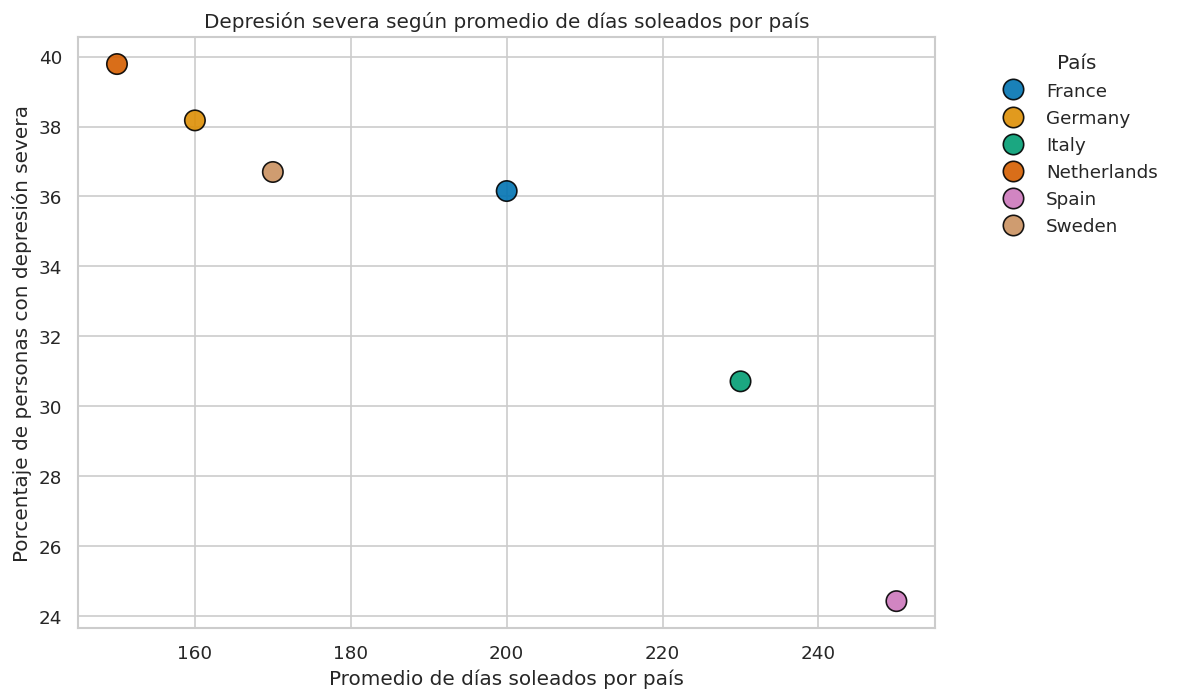

In [60]:
# Filtrar únicamente personas con depresión severa
grafico_severo = grafico_dep_sol[
    grafico_dep_sol["depression_severity"] == "Severe"
]

# Gráfico de dispersión
plt.figure(figsize=(10,6), dpi=120)

sns.scatterplot(
    data=grafico_severo,
    x="average_sunny_days",
    y="porcentaje",
    hue="country",
    s=150,
    alpha=0.9,
    edgecolor="black"
)

plt.title("Depresión severa según promedio de días soleados por país")

plt.xlabel("Promedio de días soleados por país")
plt.ylabel("Porcentaje de personas con depresión severa")

plt.legend(
    title="País",
    bbox_to_anchor=(1.05,1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.show()

**Lectura**: Se observa una tendencia inversa entre el promedio de días soleados y la proporción de personas con depresión severa. En general, los países con menos días soleados presentan mayores porcentajes de depresión severa, mientras que aquellos con más días de sol muestran proporciones menores. En particular, Países Bajos registra el porcentaje más alto de depresión severa con uno de los promedios más bajos de días soleados, mientras que España, el país con mayor cantidad de días soleados, presenta la menor proporción de depresión severa.

###Pregunta 2. ¿Cómo varía el nivel de ansiedad según el tiempo diario dedicado al consumo de noticias y al uso de redes sociales?
Variables:
* Nivel de ansiedad (anxiety_level): categórica
* Tiempo de consumo de noticias (news_hours_per_day): numérica
* Tiempo de uso de redes sociales (social_media_use_hours): numérica

**Gráfico 2. Heatmap (Mapa de calor)**

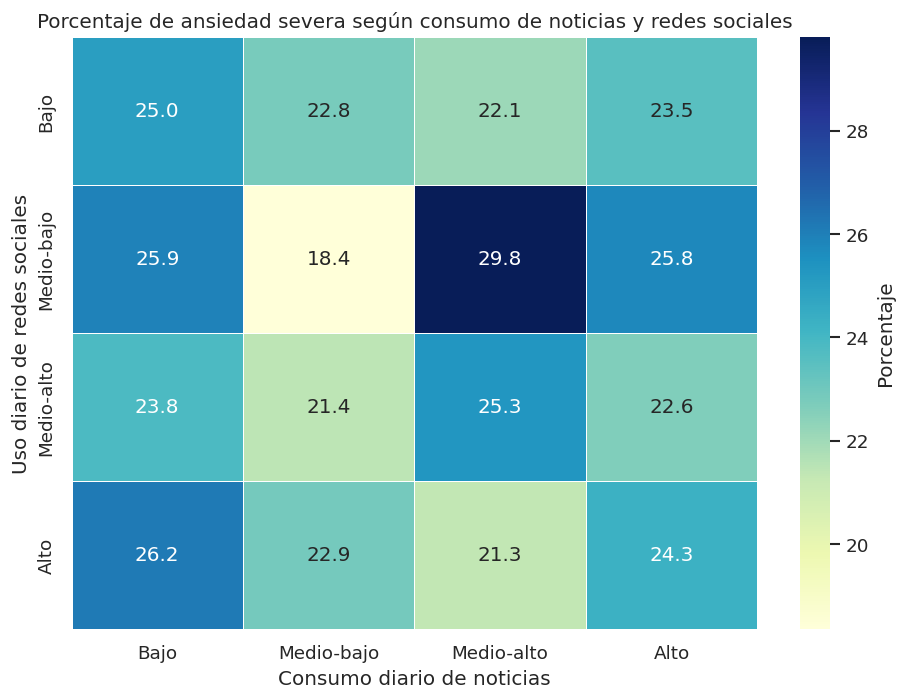

In [61]:
# Mapa de calor (del porcentaje de personas con ansiedad severa según el tiempo dedicado a redes sociales y noticias)

plt.figure(figsize=(8,6), dpi=120)

sns.heatmap(
    tabla_heatmap,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Porcentaje"}
)

plt.title(
    "Porcentaje de ansiedad severa según consumo de noticias y redes sociales"
)

plt.xlabel("Consumo diario de noticias")
plt.ylabel("Uso diario de redes sociales")

plt.tight_layout()

plt.show()

**Lectura**: Se observa que el porcentaje de personas con ansiedad severa varía según la combinación del tiempo dedicado al consumo de noticias y al uso de redes sociales. El valor más alto (29,8%) corresponde a quienes presentan un uso medio-bajo de redes sociales y un consumo medio-alto de noticias, mientras que el más bajo (18,4%) se registra entre quienes tienen un uso medio-bajo de redes sociales y un consumo medio-bajo de noticias. En conjunto, no se aprecia un patrón lineal claro entre ambas variables y el nivel de ansiedad severa.

###Pregunta 3. ¿Qué características sociodemográficas (edad, género y situación laboral) predominan entre las personas con distintos niveles de severidad de la depresión?
Variables:
* Severidad de depresión (depression_severity): categórica
* Edad (age): numérica
* Género (gender): categórica
* Situación laboral (employment_status): categórica

**Gráfico 3.1: Boxplot (diagrama de caja)**

/tmp/ipykernel_2214/991630625.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


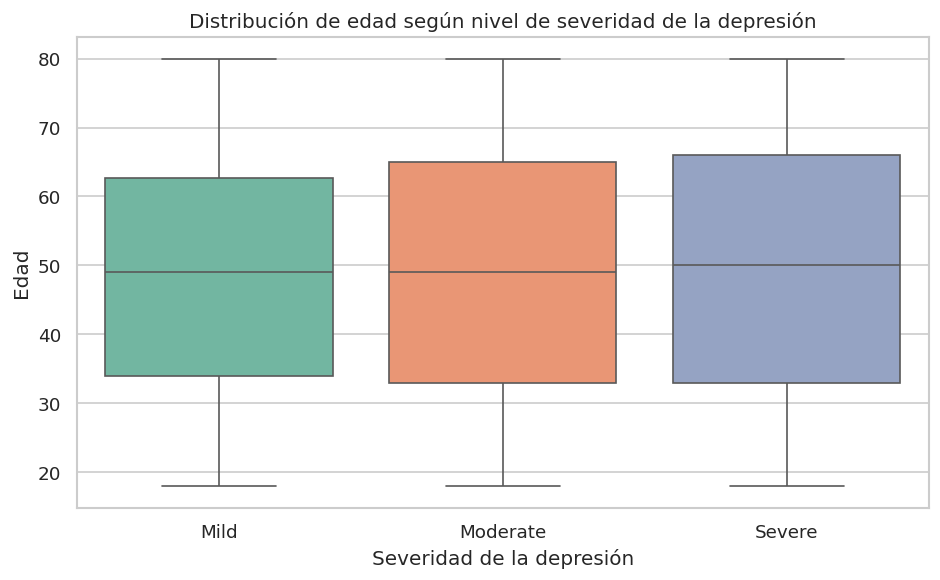

In [62]:
# Edad según severidad de depresión

plt.figure(figsize=(8,5), dpi=120)

sns.boxplot(
    data=data_set_limpio,
    x="depression_severity",
    y="age",
    palette="Set2"
)

plt.title(
    "Distribución de edad según nivel de severidad de la depresión"
)

plt.xlabel("Severidad de la depresión")
plt.ylabel("Edad")

plt.tight_layout()

plt.show()

**Lectura**: La distribución de la edad es muy similar entre los tres niveles de severidad de la depresión (leve, moderada y severa). En todos los casos, la mediana se ubica alrededor de los 49-50 años, mientras que el rango intercuartílico y la dispersión de las edades son prácticamente iguales. Además, no se observan diferencias marcadas ni valores atípicos relevantes entre los grupos, lo que sugiere que la edad no presenta variaciones importantes según la severidad de la depresión en este conjunto de datos.

**Gráfico 3.2: Barplot (gráfico de barras)**

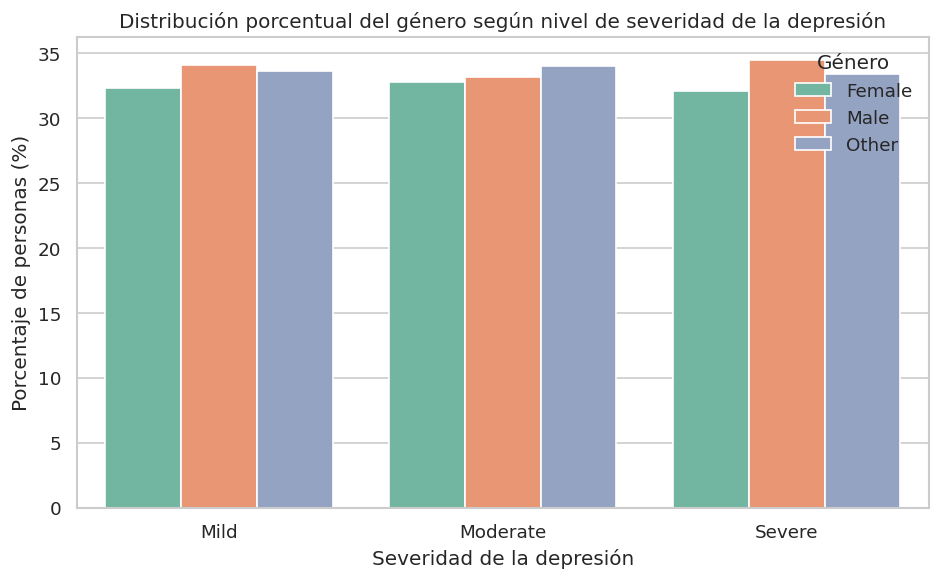

In [63]:
# Género según severidad de depresión

plt.figure(figsize=(8,5), dpi=120)

sns.barplot(
    data=genero_dep,
    x="depression_severity",
    y="porcentaje",
    hue="gender",
    palette="Set2"
)

plt.title(
    "Distribución porcentual del género según nivel de severidad de la depresión"
)

plt.xlabel("Severidad de la depresión")
plt.ylabel("Porcentaje de personas (%)")

plt.legend(
    title="Género",
    frameon=False
)

plt.tight_layout()

plt.show()

**Lectura**: La distribución porcentual del género es muy similar en los tres niveles de severidad de la depresión. En las categorías de depresión leve, moderada y severa, los hombres y las personas de otro género presentan porcentajes levemente superiores a los de las mujeres, aunque las diferencias son reducidas (alrededor de 2 puntos porcentuales). En conjunto, no se observan variaciones importantes en la composición por género según la severidad de la depresión.

**Gráfico 3.3: Barplot (gráfico de barras)**

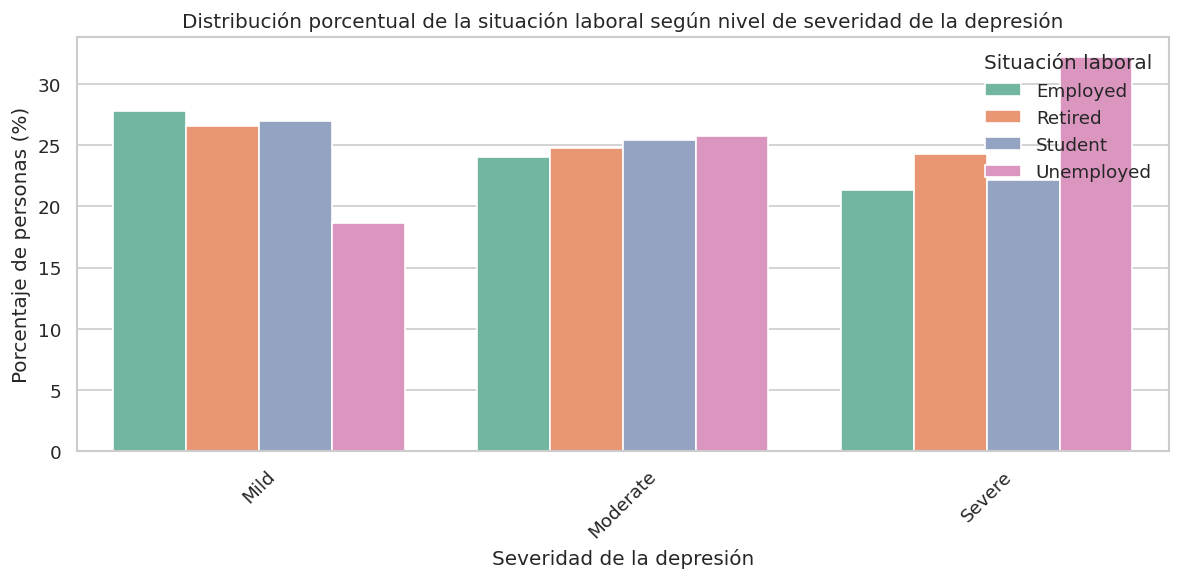

In [64]:
# Situación laboral según severidad de depresión

plt.figure(figsize=(10,5), dpi=120)

sns.barplot(
    data=empleo_dep,
    x="depression_severity",
    y="porcentaje",
    hue="employment_status",
    palette="Set2"
)

plt.title(
    "Distribución porcentual de la situación laboral según nivel de severidad de la depresión"
)

plt.xlabel("Severidad de la depresión")
plt.ylabel("Porcentaje de personas (%)")

plt.xticks(rotation=45)

plt.legend(
    title="Situación laboral",
    frameon=False
)

plt.tight_layout()

plt.show()

**Lectura**: Se observa que la distribución de la situación laboral varía según el nivel de severidad de la depresión. En los casos de depresión leve predominan las personas empleadas, mientras que las desempleadas representan el menor porcentaje. En la depresión moderada la distribución es relativamente uniforme entre las distintas situaciones laborales. En cambio, en la depresión severa aumenta la proporción de personas desempleadas, que constituye el grupo más numeroso, mientras disminuye la proporción de personas empleadas y estudiantes. En conjunto, el gráfico sugiere una mayor presencia de desempleo a medida que aumenta la severidad de la depresión.

##4.5.Síntesis de hallazgos

En primer lugar, se observa que los países con menor promedio de días soleados presentan una mayor proporción de personas con depresión severa.

En segundo lugar, no se identifica un patrón claro entre el nivel de ansiedad y la combinación del tiempo dedicado al consumo de noticias y al uso de redes sociales.

Por último, respecto de las características sociodemográficas, la edad y el género muestran distribuciones similares entre los distintos niveles de severidad de la depresión, mientras que el desempleo es más frecuente entre las personas con depresión severa.

Estos resultados describen las relaciones observadas en el dataset analizado y no permiten establecer relaciones causales entre las variables.

#Exportación del "data_set_limpio" para posterior uso en Power Bi

In [65]:
# Exportar tablas para Power BI

with pd.ExcelWriter("dataset_powerbi.xlsx", engine="openpyxl") as writer:

    data_set_limpio.to_excel(writer, sheet_name="data_limpio", index=False)
    grafico_dep_sol.to_excel(writer, sheet_name="pregunta1", index=False)
    ansiedad_severa.to_excel(writer, sheet_name="pregunta2", index=False)
    genero_dep.to_excel(writer, sheet_name="pregunta3_genero", index=False)
    empleo_dep.to_excel(writer, sheet_name="pregunta3_empleo", index=False)

print("Archivo dataset_powerbi.xlsx creado correctamente.")

Archivo dataset_powerbi.xlsx creado correctamente.


In [66]:
# Descarga de "dataset_powerbi.xlsx"

from google.colab import files
files.download("dataset_powerbi.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>